<a href="https://colab.research.google.com/github/andresanchez256/Portafolio/blob/main/Proyecto_Serie_Financiera.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
# ============================================================
# CELDA 1: INSTALAR LIBRERÍAS
# ============================================================
!pip install yfinance prophet pandas numpy matplotlib seaborn statsmodels scikit-learn -q

print("✅ Librerías instaladas correctamente")

✅ Librerías instaladas correctamente


In [2]:
# ============================================================
# CELDA 2: IMPORTAR LIBRERÍAS
# ============================================================
import yfinance as yf
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from prophet import Prophet
from sklearn.metrics import mean_absolute_error, mean_squared_error
import warnings
warnings.filterwarnings('ignore')

print("✅ Librerías importadas correctamente")

✅ Librerías importadas correctamente


In [3]:
# ============================================================
# CELDA 3: CONFIGURACIÓN INICIAL
# ============================================================
# Configurar estilo de gráficos
sns.set_style("darkgrid")
plt.rcParams['figure.figsize'] = (12, 6)

# Seleccionar el ticker (cambia "AAPL" por cualquier otro: "GOOGL", "MSFT", "TSLA", etc.)
TICKER = "AAPL"
PERIOD = "2y"  # Últimos 2 años de datos

print(f"📊 Descargando datos de {TICKER}...")

📊 Descargando datos de AAPL...


In [4]:
# ============================================================
# CELDA 4: DESCARGAR DATOS CON YFINANCE
# ============================================================
df = yf.download(TICKER, period=PERIOD, progress=False)
df = df[['Close']].copy()
df.columns = ['price']

print(f"✅ Datos descargados: {len(df)} registros")
print(f"📅 Desde: {df.index.min()} - Hasta: {df.index.max()}")

# Mostrar los primeros registros
df.head()

✅ Datos descargados: 500 registros
📅 Desde: 2024-06-24 00:00:00 - Hasta: 2026-06-22 00:00:00


,price
Date,
2024-06-24,206.352478
2024-06-25,207.274521
2024-06-26,211.418579
2024-06-27,212.261292
2024-06-28,208.811203


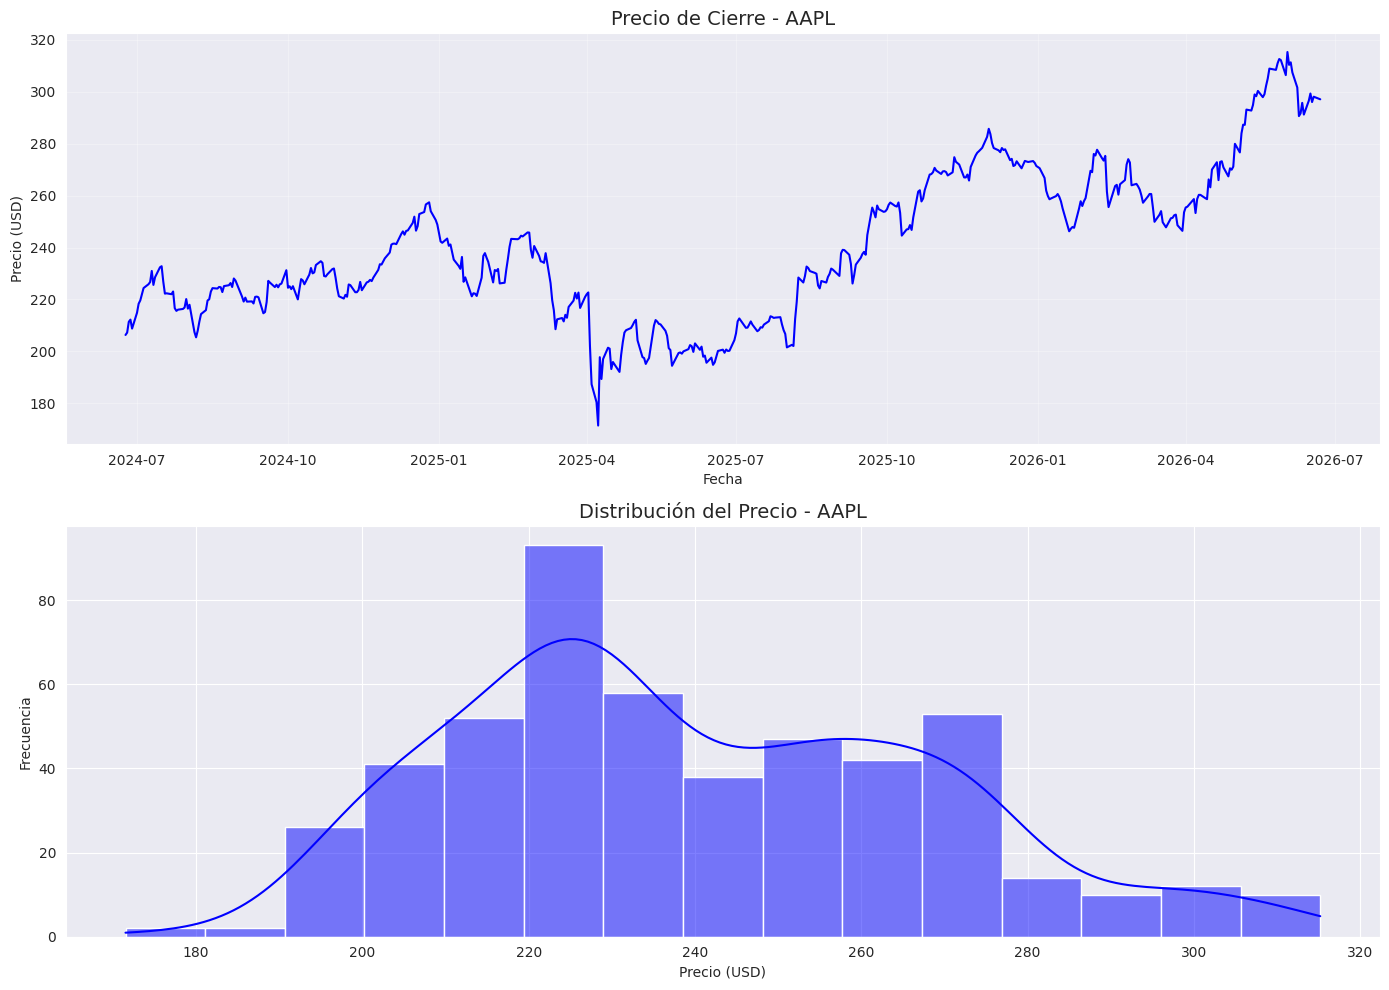

In [5]:
# ============================================================
# CELDA 5: VISUALIZAR SERIE TEMPORAL
# ============================================================
fig, axes = plt.subplots(2, 1, figsize=(14, 10))

# Gráfico principal
axes[0].plot(df.index, df['price'], color='blue', linewidth=1.5)
axes[0].set_title(f'Precio de Cierre - {TICKER}', fontsize=14)
axes[0].set_xlabel('Fecha')
axes[0].set_ylabel('Precio (USD)')
axes[0].grid(True, alpha=0.3)

# Gráfico de distribución
sns.histplot(df['price'], kde=True, ax=axes[1], color='blue')
axes[1].set_title(f'Distribución del Precio - {TICKER}', fontsize=14)
axes[1].set_xlabel('Precio (USD)')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

In [6]:
# ============================================================
# CELDA 6: FUNCIÓN TEST ADF (ESTACIONARIEDAD)
# ============================================================
def adf_test(series):
    """Función para realizar test de Dickey-Fuller"""
    result = adfuller(series, autolag='AIC')
    print(f"\n📊 Test ADF - {TICKER}")
    print(f"Estadístico: {result[0]:.4f}")
    print(f"p-valor: {result[1]:.4f}")
    print(f"Valor crítico 5%: {result[4]['5%']:.4f}")

    if result[1] <= 0.05:
        print("✅ La serie es ESTACIONARIA (p-valor < 0.05)")
        return True
    else:
        print("❌ La serie NO es estacionaria (p-valor > 0.05)")
        return False

# Ejecutar test
is_stationary = adf_test(df['price'])


📊 Test ADF - AAPL
Estadístico: -1.1279
p-valor: 0.7038
Valor crítico 5%: -2.8673
❌ La serie NO es estacionaria (p-valor > 0.05)


In [7]:
# ============================================================
# CELDA 7: DIFERENCIACIÓN (si es necesario)
# ============================================================
if not is_stationary:
    print("\n🔄 Aplicando diferenciación...")
    df['price_diff'] = df['price'].diff()
    is_stationary_diff = adf_test(df['price_diff'].dropna())

    if is_stationary_diff:
        print("✅ La serie diferenciada es ESTACIONARIA")
        series_for_model = df['price_diff'].dropna()
    else:
        print("⚠️ La serie diferenciada sigue sin ser estacionaria")
        series_for_model = df['price_diff'].dropna()
else:
    series_for_model = df['price']

print(f"\n📊 Serie a utilizar: {len(series_for_model)} registros")


🔄 Aplicando diferenciación...

📊 Test ADF - AAPL
Estadístico: -21.3033
p-valor: 0.0000
Valor crítico 5%: -2.8674
✅ La serie es ESTACIONARIA (p-valor < 0.05)
✅ La serie diferenciada es ESTACIONARIA

📊 Serie a utilizar: 499 registros


In [8]:
# ============================================================
# CELDA 8: FUNCIÓN PARA ARIMA
# ============================================================
def run_arima(series, order=(5,1,0), test_size=30):
    """Función para ejecutar modelo ARIMA"""
    # Dividir datos
    train = series[:-test_size]
    test = series[-test_size:]

    # Entrenar modelo
    print(f"\n🔄 Entrenando modelo ARIMA{order}...")
    model = ARIMA(train, order=order).fit()

    # Predecir
    print("🔮 Generando predicciones...")
    forecast = model.forecast(steps=len(test))

    # Calcular métricas
    mae = mean_absolute_error(test, forecast)
    rmse = np.sqrt(mean_squared_error(test, forecast))
    mape = np.mean(np.abs((test - forecast) / test)) * 100

    print(f"\n📊 MÉTRICAS ARIMA:")
    print(f"MAE: {mae:.4f}")
    print(f"RMSE: {rmse:.4f}")
    print(f"MAPE: {mape:.2f}%")

    return model, forecast, test, mae, rmse, mape


🔄 Entrenando modelo ARIMA(5, 1, 0)...
🔮 Generando predicciones...

📊 MÉTRICAS ARIMA:
MAE: 3.3457
RMSE: 4.6309
MAPE: nan%


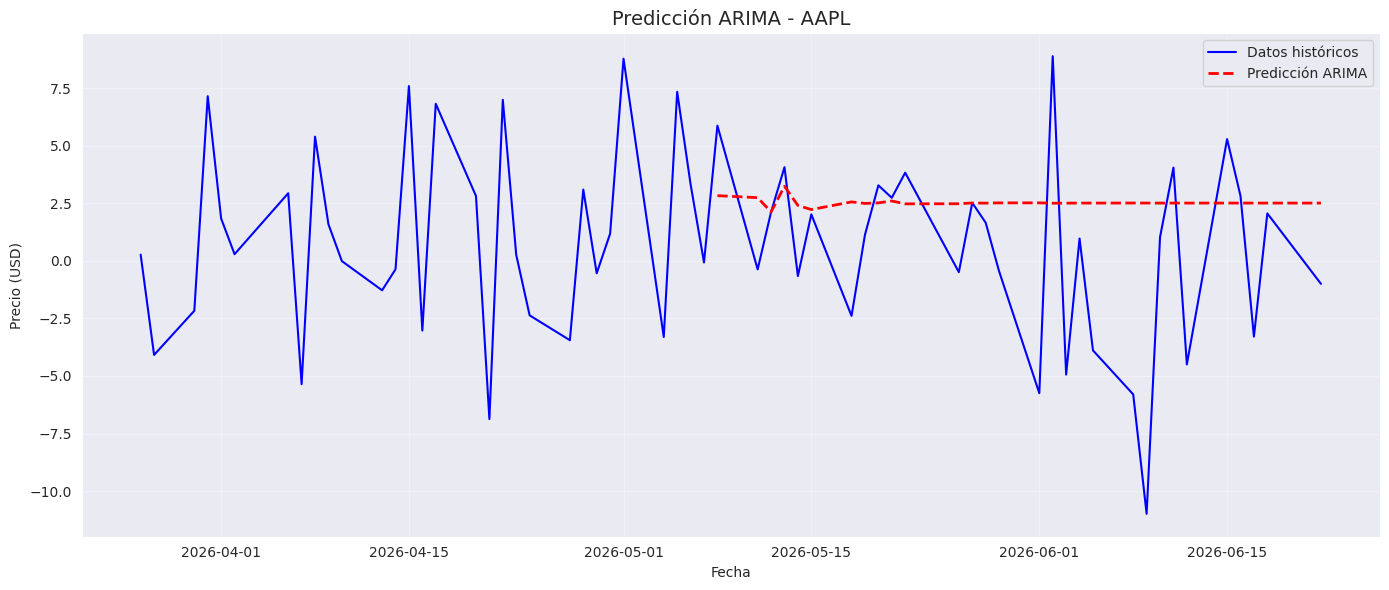

In [9]:
# ============================================================
# CELDA 9: EJECUTAR ARIMA
# ============================================================
# Ejecutar modelo
arima_model, forecast, test, mae, rmse, mape = run_arima(series_for_model, order=(5,1,0), test_size=30)

# Visualizar predicciones ARIMA
fig, ax = plt.subplots(figsize=(14, 6))

# Mostrar últimos 60 días
ax.plot(series_for_model.index[-60:], series_for_model[-60:],
        label='Datos históricos', color='blue', linewidth=1.5)
ax.plot(test.index, forecast,
        label='Predicción ARIMA', color='red', linestyle='--', linewidth=2)

ax.set_title(f'Predicción ARIMA - {TICKER}', fontsize=14)
ax.set_xlabel('Fecha')
ax.set_ylabel('Precio (USD)')
ax.legend()
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [10]:
# ============================================================
# CELDA 10: PREPARAR DATOS PARA PROPHET
# ============================================================
print("\n🔄 Preparando datos para Prophet...")

# Prophet necesita columnas 'ds' (fecha) y 'y' (valor)
df_prophet = df[['price']].reset_index()
df_prophet.columns = ['ds', 'y']
df_prophet['ds'] = pd.to_datetime(df_prophet['ds'])

print(f"✅ Datos listos para Prophet: {len(df_prophet)} registros")
df_prophet.head()


🔄 Preparando datos para Prophet...
✅ Datos listos para Prophet: 500 registros


,ds,y
0,2024-06-24,206.352478
1,2024-06-25,207.274521
2,2024-06-26,211.418579
3,2024-06-27,212.261292
4,2024-06-28,208.811203


In [11]:
# ============================================================
# CELDA 11: ENTRENAR PROPHET
# ============================================================
print("🔄 Entrenando Prophet...")

# Crear modelo
prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=True,
    daily_seasonality=False
)

# Entrenar
prophet_model.fit(df_prophet)

print("✅ Modelo Prophet entrenado correctamente")

🔄 Entrenando Prophet...
✅ Modelo Prophet entrenado correctamente


In [12]:
# ============================================================
# CELDA 12: GENERAR PREDICCIONES CON PROPHET
# ============================================================
# Crear futuro (30 días adicionales)
future = prophet_model.make_future_dataframe(periods=30)

# Predecir
forecast_prophet = prophet_model.predict(future)

print(f"✅ Predicciones generadas: {len(forecast_prophet)} registros")
forecast_prophet[['ds', 'yhat', 'yhat_lower', 'yhat_upper']].tail()

✅ Predicciones generadas: 530 registros


,ds,yhat,yhat_lower,yhat_upper
525,2026-07-18,318.691033,311.550017,326.154774
526,2026-07-19,318.750414,311.358271,326.092498
527,2026-07-20,340.200120,332.613706,347.736275
528,2026-07-21,340.369388,332.443829,347.998030
529,2026-07-22,340.556185,332.604493,348.536446


In [13]:
# ============================================================
# CELDA 13: EVALUAR PROPHET
# ============================================================
# Usar los últimos 30 días como test
prophet_test = df_prophet[-30:]
prophet_pred = forecast_prophet[-30:]

# Calcular métricas
mae_prophet = mean_absolute_error(prophet_test['y'], prophet_pred['yhat'])
rmse_prophet = np.sqrt(mean_squared_error(prophet_test['y'], prophet_pred['yhat']))
mape_prophet = np.mean(np.abs((prophet_test['y'] - prophet_pred['yhat']) / prophet_test['y'])) * 100

print(f"\n📊 MÉTRICAS PROPHET:")
print(f"MAE: {mae_prophet:.4f}")
print(f"RMSE: {rmse_prophet:.4f}")
print(f"MAPE: {mape_prophet:.2f}%")


📊 MÉTRICAS PROPHET:
MAE: 22.6491
RMSE: 26.8630
MAPE: nan%


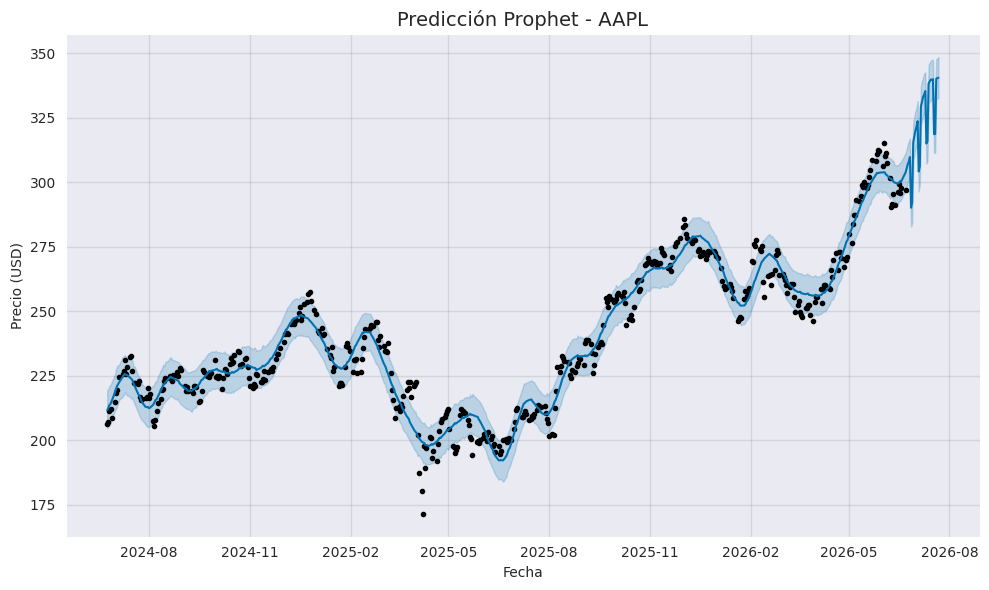

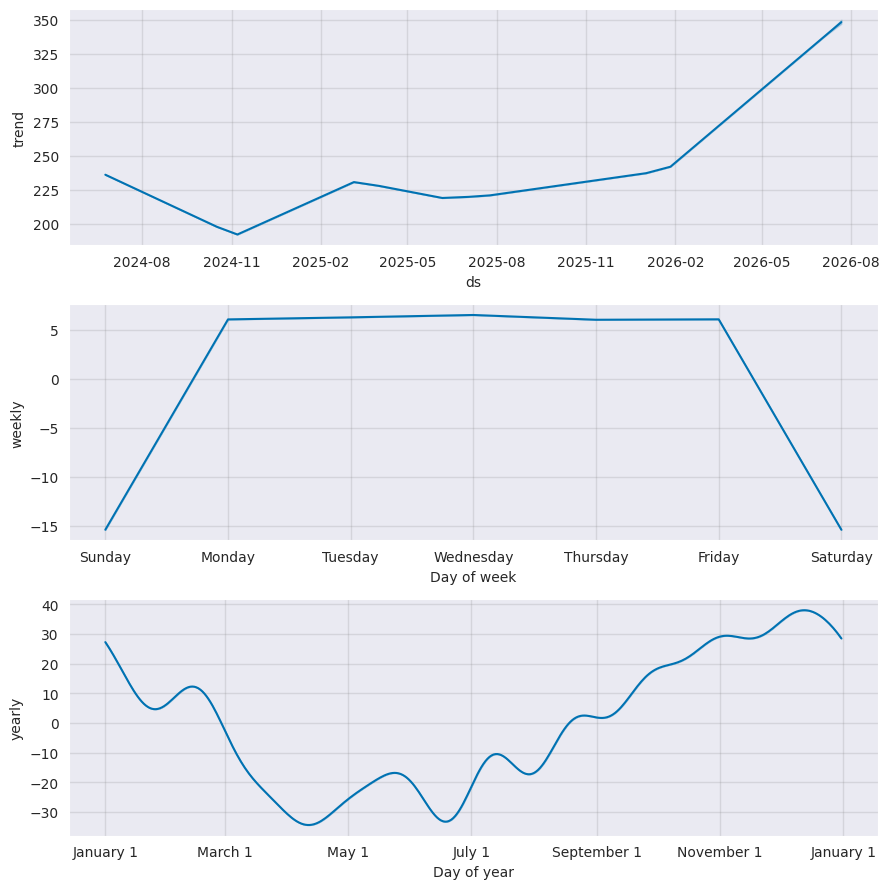

In [14]:
# ============================================================
# CELDA 14: VISUALIZAR PROPHET
# ============================================================
fig = prophet_model.plot(forecast_prophet, xlabel='Fecha', ylabel='Precio (USD)')
plt.title(f'Predicción Prophet - {TICKER}', fontsize=14)
plt.tight_layout()
plt.show()

# Componentes de la serie
fig2 = prophet_model.plot_components(forecast_prophet)
plt.tight_layout()
plt.show()


📊 COMPARATIVA DE MODELOS
 Modelo       MAE      RMSE  MAPE (%)
  ARIMA  3.345709  4.630856       NaN
Prophet 22.649114 26.863006       NaN



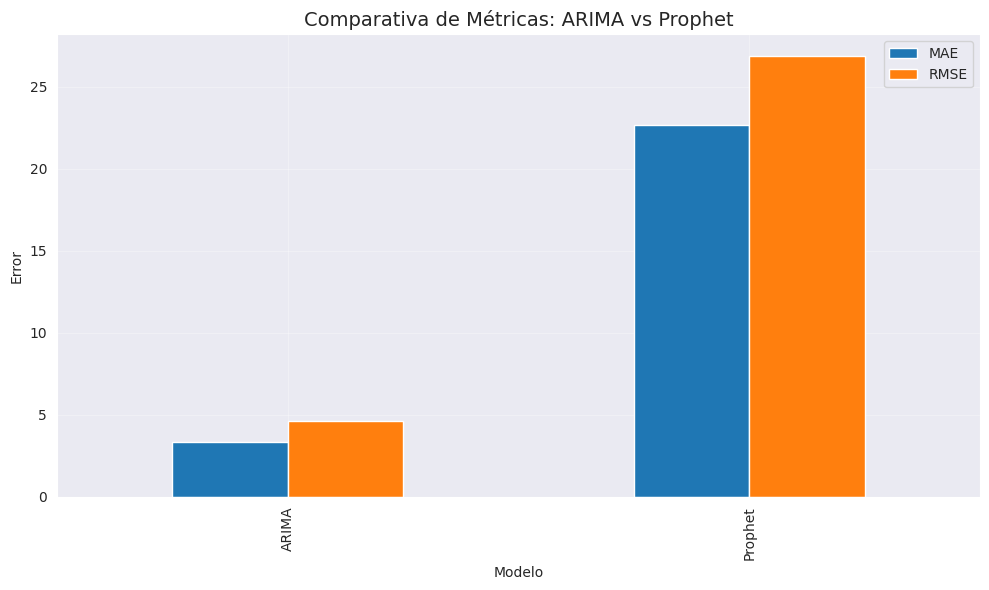

In [15]:
# ============================================================
# CELDA 15: COMPARATIVA DE MODELOS
# ============================================================
print("\n" + "="*55)
print("📊 COMPARATIVA DE MODELOS")
print("="*55)

comparison = pd.DataFrame({
    'Modelo': ['ARIMA', 'Prophet'],
    'MAE': [mae, mae_prophet],
    'RMSE': [rmse, rmse_prophet],
    'MAPE (%)': [mape, mape_prophet]
})

print(comparison.to_string(index=False))
print("\n" + "="*55)

# Gráfico comparativo de métricas
fig, ax = plt.subplots(figsize=(10, 6))
comparison.set_index('Modelo')[['MAE', 'RMSE']].plot(kind='bar', ax=ax)
ax.set_title('Comparativa de Métricas: ARIMA vs Prophet', fontsize=14)
ax.set_ylabel('Error')
ax.set_xlabel('Modelo')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()